In [1]:
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

TypeError: Dimensions of C (744, 301, 301) should be one smaller than X(302) and Y(301) while using shading='flat' see help(pcolormesh)

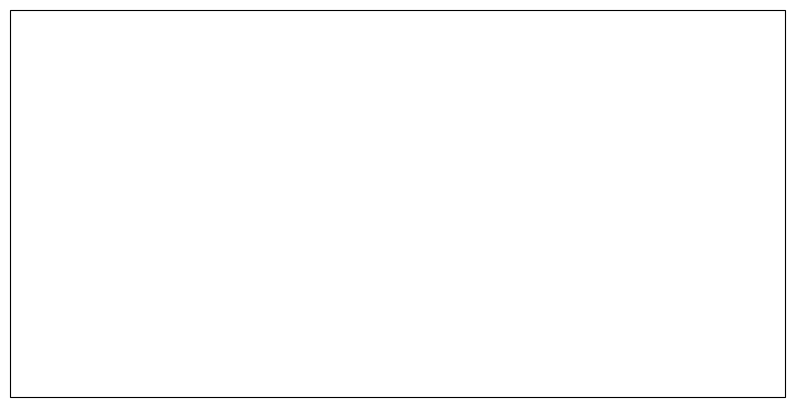

In [2]:
from pathlib import Path
import numpy as np

DATA_PATH = Path("data/raw/netcdf/era5_2023_01.nc")


def open_ds(path=DATA_PATH):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")
    return xr.open_dataset(path)


def _find_coord_names(ds):
    lon_candidates = ["lon", "longitude", "long"]
    lat_candidates = ["lat", "latitude"]
    lon = next((n for n in lon_candidates if n in ds.coords or n in ds), None)
    lat = next((n for n in lat_candidates if n in ds.coords or n in ds), None)
    if lon is None or lat is None:
        raise KeyError("Could not find longitude/latitude coordinate names in dataset")
    return lon, lat


def plot_variable(ds, var_name="t2m", time_idx=0, cmap="coolwarm", figsize=(10, 8)):
    if var_name not in ds.data_vars:
        raise KeyError(f"Variable '{var_name}' not found in dataset (available: {list(ds.data_vars)})")
    lon_name, lat_name = _find_coord_names(ds)
    data = ds[var_name]
    if "time" in data.dims:
        data2d = data.isel(time=time_idx)
        time_str = str(data.time.values[time_idx])
    else:
        data2d = data
        time_str = ""
    lon = ds[lon_name]
    lat = ds[lat_name]
    if lon.ndim == 1 and lat.ndim == 1:
        Lon, Lat = np.meshgrid(lon, lat)
    else:
        Lon, Lat = lon, lat
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw=dict(projection=ccrs.PlateCarree()))
    pcm = ax.pcolormesh(Lon, Lat, data2d, transform=ccrs.PlateCarree(), cmap=cmap)
    ax.coastlines()
    ax.set_title(f"{var_name} {time_str}".strip())
    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical', label=str(getattr(data, 'units', '')))
    plt.show()
    return fig, ax


# example
if __name__ == "__main__":
    ds = open_ds()
    plot_variable(ds, "t2m", time_idx=0)